# Quantize Limite 1B Violetto on a Mac mini M4

Convert the original `paradigma-inc/limite-1b-violetto` checkpoint into an unquantized MLX baseline and an affine 4-bit derivative, then compare runtime, memory, and held-out mathematical accuracy. This is a text-only mathematical reasoning model, with a custom architecture and a fixed chat template.

Install `requirements.txt` before starting this kernel. The pinned community `limite-mlx` adapter registers the architecture without editing mlx-lm. Its numerical equivalence claims have not been independently reproduced here; both variants use the same adapter. No weights are uploaded by this notebook.

## 1. Reproducible setup

Requires an Apple Silicon Mac and about 5 GiB of free disk space. Source weights contain BF16 matrices and small FP32 auxiliary tensors; the adapter preserves those auxiliary tensors. This workflow performs no training or validation-set tuning. GSM8K's training split is unused and its test split is reserved for the final paired evaluation.
The reference run targets a Mac mini M4 with 16 GiB unified memory. The setup records the actual hostname, chip, hardware model, memory, macOS, and Python version in `benchmark_artifacts/hardware.json`.


In [1]:
import gc
import hashlib
import json
import platform
import subprocess
import sys
from importlib.metadata import version
from pathlib import Path

import mlx.core as mx
from huggingface_hub import snapshot_download
from mlx_lm import generate, load
from mlx_lm.convert import convert
from mlx_lm.sample_utils import make_sampler
from IPython.display import Image, display

if platform.system() != 'Darwin' or platform.machine() != 'arm64':
    raise RuntimeError('MLX requires an Apple Silicon Mac.')
MODULE_DIR = Path.cwd().resolve()
if not (MODULE_DIR / 'benchmark_accuracy.py').is_file():
    raise FileNotFoundError('Run this notebook from the Violetto repository root.')
ARTIFACT_DIR = MODULE_DIR / 'artifacts'
ARTIFACT_DIR.mkdir(exist_ok=True)
SOURCE_ID = 'paradigma-inc/limite-1b-violetto'
SOURCE_REVISION = '9402e422e87b220507963cd42c997459c1e87b43'
BASELINE_DIR = ARTIFACT_DIR / 'limite-1b-violetto-bf16-mlx'
QUANTIZED_DIR = ARTIFACT_DIR / 'limite-1b-violetto-4bit'
REPORT_DIR = MODULE_DIR / 'benchmark_artifacts'
REPORT_DIR.mkdir(exist_ok=True)
print(f'Platform: {platform.platform()}')
print(f'Adapter: limite-mlx {version("limite-mlx")}')
hardware = {'hostname': platform.node(), 'platform': platform.platform(),
            'chip': subprocess.check_output(['sysctl', '-n', 'machdep.cpu.brand_string'], text=True).strip(),
            'model': subprocess.check_output(['sysctl', '-n', 'hw.model'], text=True).strip(),
            'memory_bytes': int(subprocess.check_output(['sysctl', '-n', 'hw.memsize'], text=True)),
            'python': platform.python_version()}
(REPORT_DIR / 'hardware.json').write_text(json.dumps(hardware, indent=2) + '\n')
print(hardware)


/Users/marco/violetto-mlx-20260924/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Platform: macOS-26.4-arm64-arm-64bit-Mach-O
Adapter: limite-mlx 0.1.0
{'hostname': 'Mac.homenet.telecomitalia.it', 'platform': 'macOS-26.4-arm64-arm-64bit-Mach-O', 'chip': 'Apple M4', 'model': 'Mac16,10', 'memory_bytes': 17179869184, 'python': '3.13.15'}


## 2. Download a pinned snapshot and convert both variants

Both conversions start from the same original snapshot. The baseline is not dequantized from 4-bit weights. Quantization uses 4 bits and group size 64, including the tied embedding/output head. The adapter folds the learned attention projection scales before quantization. A completion manifest prevents silently reusing partial or unrelated outputs. Both artifacts accept the two upstream end tokens, resolving the disagreement between the tokenizer and generation configuration without changing the prompt template.

In [2]:
source_dir = Path(snapshot_download(
    SOURCE_ID, revision=SOURCE_REVISION, local_dir=ARTIFACT_DIR / 'source',
    allow_patterns=['*.json', '*.jinja', '*.safetensors', 'README.md'],
))
provenance = {
    'source_model': SOURCE_ID, 'source_revision': SOURCE_REVISION,
    'adapter': 'limite-mlx', 'adapter_version': version('limite-mlx'),
    'adapter_revision': 'b21b7a4fa6ca05cb02082d9f7819b8d1387f2f1a',
    'mlx_version': version('mlx'), 'mlx_lm_version': version('mlx-lm'),
    'eos_token_ids': [151643, 151645],
}
for output, quantized in ((BASELINE_DIR, False), (QUANTIZED_DIR, True)):
    expected = {**provenance, 'quantized': quantized,
                'bits': 4 if quantized else None, 'group_size': 64 if quantized else None}
    manifest = output / 'conversion_manifest.json'
    if output.exists():
        if not manifest.exists() or json.loads(manifest.read_text()) != expected:
            raise RuntimeError(f'Unverified existing output: {output}. Use a fresh output path.')
        print(f'Reusing completed conversion: {output.name}')
        continue
    convert(str(source_dir), mlx_path=str(output), dtype='bfloat16',
            quantize=quantized, q_bits=4, q_group_size=64)
    for filename in ('config.json', 'generation_config.json'):
        path = output / filename
        config = json.loads(path.read_text())
        config['eos_token_id'] = [151643, 151645]
        path.write_text(json.dumps(config, indent=2) + '\n')
    manifest.write_text(json.dumps(expected, indent=2) + '\n')
    gc.collect()
    mx.clear_cache()

weight_records = {}
for output in (BASELINE_DIR, QUANTIZED_DIR):
    records = []
    for path in sorted(output.glob('*.safetensors')):
        with path.open('rb') as stream:
            digest = hashlib.file_digest(stream, 'sha256').hexdigest()
        records.append({'name': path.name, 'bytes': path.stat().st_size, 'sha256': digest})
    weight_records[output.name] = records
    print(f'{output.name}: {sum(row["bytes"] for row in records) / 2**30:.3f} GiB')
(REPORT_DIR / 'conversion_provenance.json').write_text(
    json.dumps({**provenance, 'weights': weight_records}, indent=2) + '\n')


Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

Fetching 8 files:  12%|█▎        | 1/8 [00:00<00:01,  5.03it/s]

Fetching 8 files: 100%|██████████| 8/8 [00:00<00:00, 38.89it/s]

Reusing completed conversion: limite-1b-violetto-bf16-mlx
Reusing completed conversion: limite-1b-violetto-4bit


limite-1b-violetto-bf16-mlx: 1.929 GiB


limite-1b-violetto-4bit: 0.543 GiB


787

## 3. Reload and generate

The saved 4-bit artifact is reloaded for a new mathematical question. Use the original chat template; it supplies the required system prompt and asks for a boxed answer. This demonstration uses upstream's recommended temperature 0.6 and top-p 0.95. The paired benchmark below uses greedy decoding for reproducibility instead.

In [3]:
mx.random.seed(42)
model, tokenizer = load(str(QUANTIZED_DIR))
prompt = tokenizer.apply_chat_template(
    [{'role': 'user', 'content': 'What is the sum of the integers from 1 to 20?'}],
    tokenize=False, add_generation_prompt=True,
)
answer = generate(model, tokenizer, prompt=prompt, max_tokens=1024,
                  sampler=make_sampler(temp=0.6, top_p=0.95))
print(answer)
del model, tokenizer
gc.collect()
mx.clear_cache()


[transformers] You are using a model of type `limite` to instantiate a model of type ``. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


[transformers] The tokenizer you are loading from '/Users/marco/violetto-mlx-standalone/artifacts/limite-1b-violetto-4bit' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


<think>We need to parse the user's request: "What is the sum of the integers from 1 to 20? Please reason step by step, and put your final answer within \boxed{}."

We need to answer with reasoning step by step, and final answer in a LaTeX boxed format \boxed{...}. This is straightforward: sum of integers from 1 to 20 inclusive. There are multiple ways: arithmetic series formula n(n+1)/2 for first n natural numbers. For n=20, sum = 20*21/2 = 10*21 = 210. We need to provide step-by-step reasoning. Also final answer within \boxed{210}.

We should ensure we follow the user's request: "Please reason step by step, and put your final answer within \boxed{}."

Thus we need to produce a response with reasoning, likely a short explanation, and final answer in \boxed{210}. No extra text outside the box for the final answer? They say "put your final answer within \boxed{}." Usually they want the answer inside a LaTeX \boxed{} environment. We can have the answer at the end within \boxed{210}. It's 

## 4. Paired runtime and held-out accuracy

The local benchmark scripts evaluate Violetto with four mathematical smoke questions, the original fixed chat template, and numeric extraction from the last complete boxed field outside its reasoning section. Incomplete thinking or nonnumeric boxed contents count as incorrect.

The teaching run uses 10 GSM8K test examples, seed 42, and 1,024 output tokens per answer for both variants. Dataset revision and SHA-256 are pinned in the evaluator. This small, token-limited evaluation is not a reproduction of upstream competition results: Violetto can require several thousand reasoning tokens, and unfinished or nonnumeric answers count as incorrect. For a larger run use 100 examples and 3,000 tokens, chosen before inspecting test outcomes. Do not tune quantization or prompts on this test split.

Raw answers, correct/total, Wilson intervals, paired bootstrap uncertainty, regressions, improvements, runtime, and MLX peak memory are saved. Runtime excludes loading; lengths can differ, so throughput is workload-dependent. Smoke failures are reported separately from accuracy and do not prevent saving the results.

[transformers] You are using a model of type `limite` to instantiate a model of type ``. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


[transformers] The tokenizer you are loading from '/Users/marco/violetto-mlx-standalone/artifacts/limite-1b-violetto-bf16-mlx' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


[transformers] You are using a model of type `limite` to instantiate a model of type ``. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


[transformers] The tokenizer you are loading from '/Users/marco/violetto-mlx-standalone/artifacts/limite-1b-violetto-4bit' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


platform: macOS-26.4-arm64-arm-64bit-Mach-O
cases: 4, max_tokens: 1024, sampler: default greedy

[MLX unquantized] /Users/marco/violetto-mlx-standalone/artifacts/limite-1b-violetto-bf16-mlx
[PASS] multiplication: 10.56s | <think>We need to answer the user's question: "What is 17 multiplied by 6? Please reason step by step, and put your final answer within \boxed{}."

We need to compute 17 * 6 = 102. Provide step-by-step reasoning. Then final answer in \boxed{102}. That's straightforward. Ensure we follow instructions: reason step by step, final answer within \boxed{}. No extra text outside? The user says "Please reason step by step, and put your final answer within \boxed{}." So we can provide reasoning and then final answer in a box. That's fine.

We need to ensure we output only final answer? The instruction says reason step by step, so we should include reasoning. Then final answer in \boxed{}. That's acceptable.

Thus: 17*6 = (10+7)*6 = 60+42 = 102. Or 6*17 = 6*10 + 6*7 = 60+42 = 1

...

[transformers] You are using a model of type `limite` to instantiate a model of type ``. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


[transformers] The tokenizer you are loading from '/Users/marco/violetto-mlx-20260924/20-mlx-quantization/violetto/artifacts/limite-1b-violetto-4bit' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


  1/10 | correct: 0


  10/10 | correct: 5
Accuracy delta: +0.00 pp

artifacts: /Users/marco/violetto-mlx-standalone/benchmark_artifacts


Smoke checks: all passed


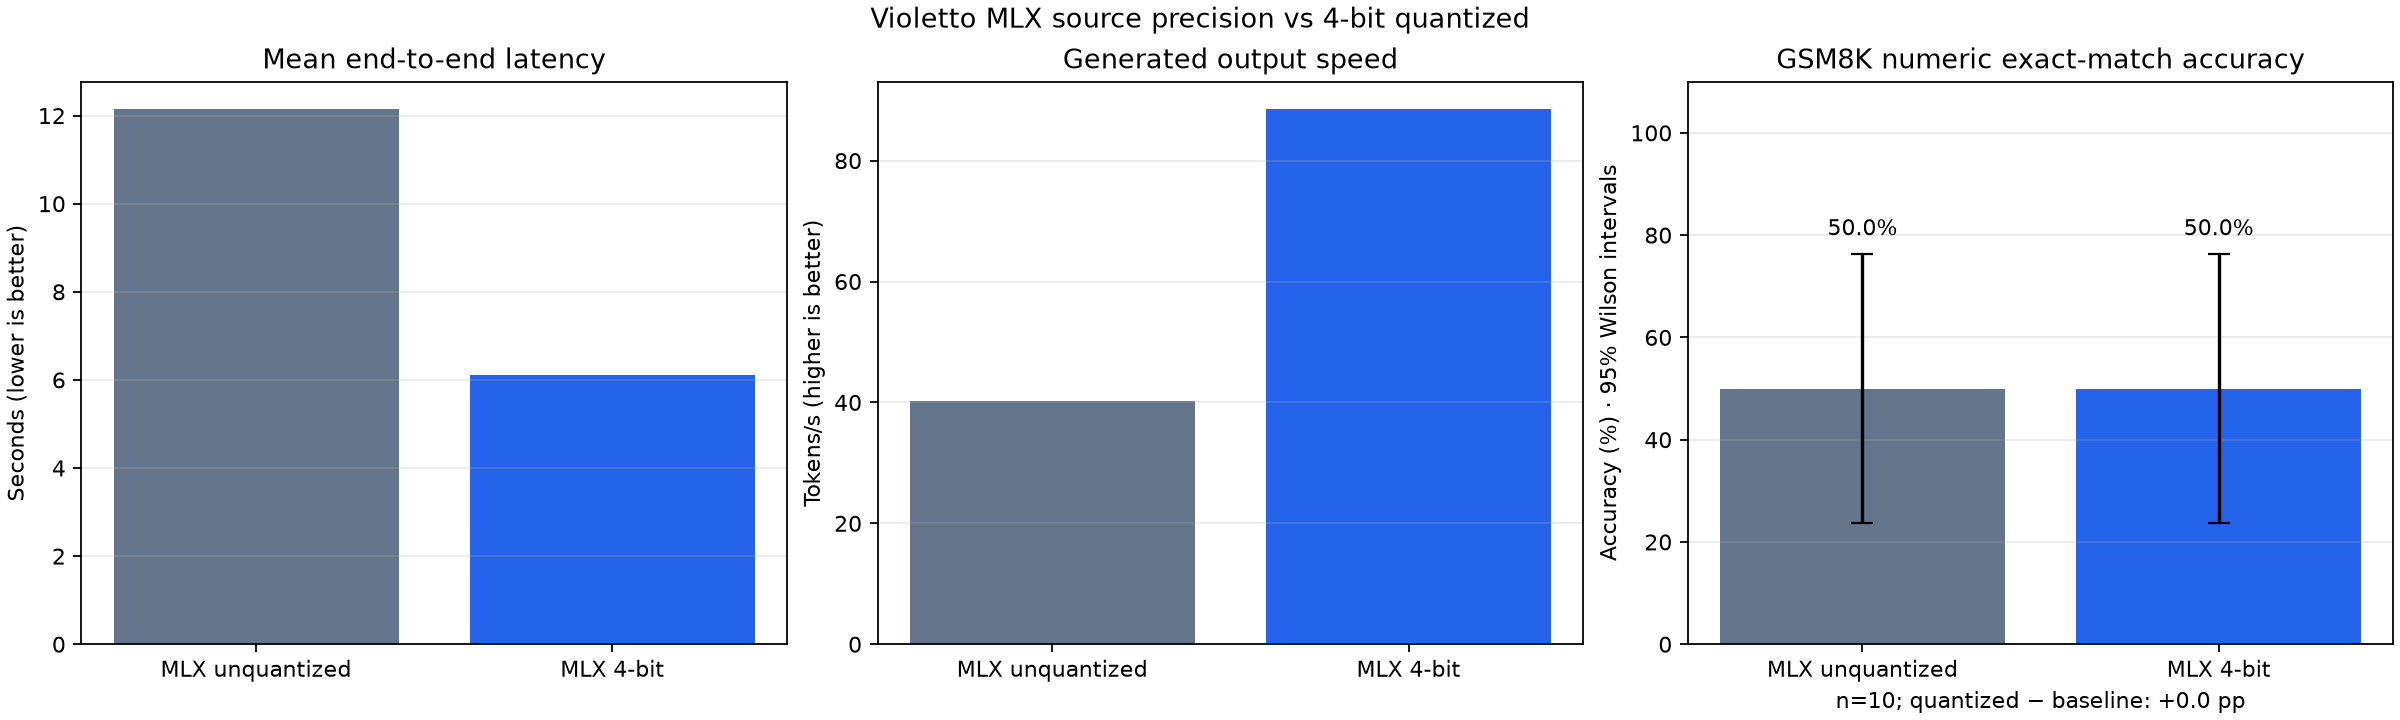

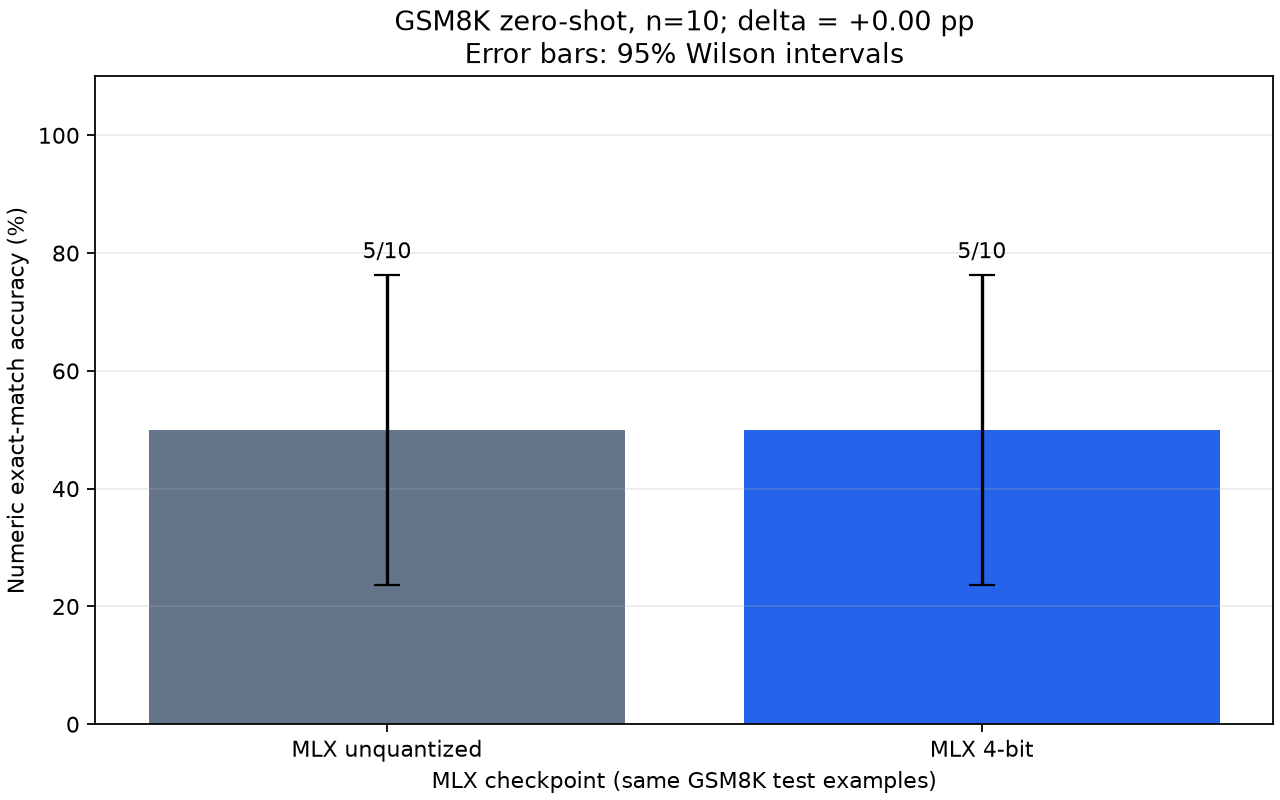

In [4]:
ACCURACY_SAMPLES = 10
MAX_TOKENS = 1024
command = [
    sys.executable, str(MODULE_DIR / 'benchmark_mlx.py'),
    '--baseline-model', str(BASELINE_DIR), '--model', str(QUANTIZED_DIR),
    '--max-tokens', str(MAX_TOKENS), '--accuracy-samples', str(ACCURACY_SAMPLES),
    '--accuracy-max-tokens', str(MAX_TOKENS), '--seed', '42',
    '--output-dir', str(REPORT_DIR),
]
accuracy_report = REPORT_DIR / 'accuracy/accuracy_results.json'
previous_mtime = accuracy_report.stat().st_mtime_ns if accuracy_report.exists() else None
result = subprocess.run(command, cwd=MODULE_DIR, check=False)
if (result.returncode not in (0, 1) or not accuracy_report.exists()
        or accuracy_report.stat().st_mtime_ns == previous_mtime):
    raise RuntimeError('Benchmark did not complete; inspect its output.')
print(f'Smoke checks: {"all passed" if result.returncode == 0 else "some failed; inspect raw answers"}')
display(Image(filename=str(REPORT_DIR / 'benchmark_comparison.png')))
display(Image(filename=str(REPORT_DIR / 'accuracy/accuracy_comparison.png')))


## Interpretation and limitations

Compare the measured paired results, not unrelated published scores. A tied small-sample result does not establish general parity. Source precision includes BF16 and FP32 tensors; it is not a pure FP32 baseline. The third-party adapter is shared by both variants, so this comparison measures quantization within that runtime, not equivalence to official vLLM. This workflow does not produce or evaluate GGUF/Ollama artifacts or image inference. Retain the Apache-2.0 attribution when redistributing weights; see the README for source links and reproducibility details.

## Measured standalone run — Mac mini M4, 2026-09-24

All notebook code cells completed on Mac mini M4 with 16 GiB unified memory.
The paired GSM8K test uses 10 examples, seed 42, greedy decoding, and a maximum
of 1,024 generated tokens per example.

| Variant | GSM8K correct/total | Mathematical smoke checks | Mean smoke latency | Output tokens/s | MLX peak memory |
| --- | ---: | ---: | ---: | ---: | ---: |
| MLX unquantized | 5/10 | 100% | 12.16 s | 40.22 | 1.974 GiB |
| MLX 4-bit | 5/10 | 100% | 6.12 s | 88.62 | 0.599 GiB |

Both variants have four invalid final answers and one additional incorrect
answer. The 95% Wilson accuracy interval is 23.66%–76.34%. All paired binary
outcomes agree, so the delta and paired bootstrap interval are zero; this
small, token-limited sample does not establish quality parity.

Weights occupy 1.929 GiB for the source-precision baseline and 0.543 GiB for
4-bit. Latency excludes loading; generated lengths differ. These measurements
come from this standalone rerun and can differ from earlier runs on the same Mac.

Reports and charts are generated locally under `benchmark_artifacts/` and are excluded from Git. Run the notebook to regenerate them.
